# UPI Fraud Detection under Extreme Class Imbalance

**Goal:** detect fraudulent UPI transactions when only **1 in 1,000** transactions is fraud, and compare the main strategies for handling imbalance:

| Strategy | Family |
|---|---|
| Do nothing (plain model) | baseline |
| Class weights / `scale_pos_weight` | cost-sensitive learning |
| SMOTE oversampling, random undersampling | resampling |
| Isolation Forest | unsupervised anomaly detection |

**What makes this project different from a typical classification notebook**
- Evaluation uses **PR-AUC, precision/recall at an alert budget and rupee-based cost**, not accuracy.
- A **time-based split** (train → validation → test), the way a real fraud system is deployed.
- **Threshold chosen on validation data only**, test set touched once at the end.
- Resampling is done **inside the pipeline**, so no synthetic samples leak into validation folds.
- Failure analysis: which *kinds* of fraud are missed, and which legitimate customers get wrongly flagged.

> ⚠️ **Data note:** real UPI fraud data is private, so transactions are **simulated** (`src/data_generator.py`) with three fraud playbooks, "stealth" fraud that looks almost normal, and "hard negative" legitimate transactions that look suspicious. Absolute numbers are therefore illustrative; the *methodology* is the point.

## 1. Setup

In [1]:
import sys, time, json, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib, lightgbm as lgb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             confusion_matrix, accuracy_score, recall_score)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from src.data_generator import generate_upi_transactions
from src.features import add_features, NUM_FEATURES, CAT_FEATURES, ALL_FEATURES

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
SEED = 42

## 2. Why accuracy is useless here

If 99.9% of transactions are legitimate, a model that **never flags anything** is 99.9% accurate, and catches zero fraud. Let's prove it.

In [2]:
df = generate_upi_transactions(n=400_000, fraud_rate=0.001, days=90, seed=SEED)
print(f"Transactions: {len(df):,} | Frauds: {df.is_fraud.sum()} | Fraud rate: {df.is_fraud.mean():.3%}")

never_fraud = DummyClassifier(strategy="most_frequent").fit(df[["amount"]], df.is_fraud)
pred = never_fraud.predict(df[["amount"]])
print(f"\n'Always predict legit' model → Accuracy: {accuracy_score(df.is_fraud, pred):.3%} | Fraud recall: {recall_score(df.is_fraud, pred):.0%}")

Transactions: 400,000 | Frauds: 400 | Fraud rate: 0.100%

'Always predict legit' model → Accuracy: 99.900% | Fraud recall: 0%


## 3. Data & exploratory analysis

Fraud is generated from three "playbooks":
- **collect_scam** – victim is tricked into approving a fake collect request (new payee, large amount)
- **takeover** – account takeover: new device, odd hours, bursts of transactions, failed PINs
- **mule** – newly opened accounts rapidly passing money along

~30% of fraud is made **stealthy** (behaves like a normal customer), and ~1.8% of legitimate transactions are **hard negatives** (travelling, new phone, big purchase). That overlap is what makes the problem realistic.

In [3]:
display(df.drop(columns=["txn_id"]).head())
fraud_types = (df[df.is_fraud == 1].groupby("_kind")
               .agg(count=("amount", "size"), median_amount=("amount", "median"),
                    stealth_share=("_stealth", "mean")).round(2))
display(fraud_types)

,timestamp,txn_type,merchant_category,amount,sender_avg_amount,amount_vs_avg_ratio,hour,sender_account_age_days,receiver_account_age_days,device_changed,new_payee,location_mismatch,txns_last_1h,failed_pin_attempts,is_fraud,_kind,_stealth,_hard_negative
0,2025-01-01 00:02:40,P2P,none,953.12,1858.37,0.513,0,999,26,0,1,1,2,0,0,legit,0,1
1,2025-01-01 00:03:03,P2M,food,164.26,133.76,1.228,0,267,618,0,0,0,0,0,0,legit,0,0
2,2025-01-01 00:06:39,P2M,electronics,5618.33,21113.77,0.266,0,859,588,1,1,1,3,0,0,legit,0,1
3,2025-01-01 00:10:42,P2M,electronics,101.32,106.79,0.949,0,331,74,0,0,1,1,0,0,legit,0,0
4,2025-01-01 00:11:46,BILL,utilities,61.47,41.24,1.491,0,1236,853,0,1,0,2,0,0,legit,0,0


,count,median_amount,stealth_share
_kind,,,
collect_scam,171,2528.00,0.30
mule,93,1209.46,0.35
takeover,136,5219.04,0.26


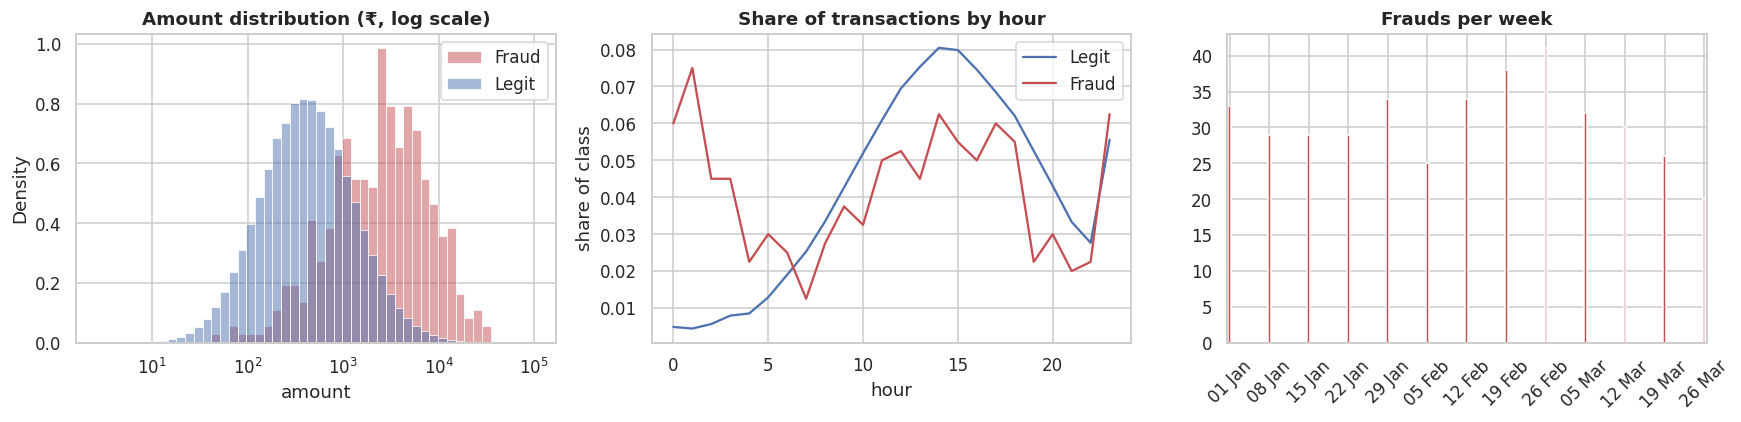

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# amount distribution (log scale), normalised within each class
sns.histplot(data=df, x="amount", hue="is_fraud", log_scale=True, stat="density", common_norm=False,
             bins=50, ax=ax[0], palette={0: "#4C72B0", 1: "#C44E52"})
ax[0].set_title("Amount distribution (₹, log scale)")
ax[0].legend(["Fraud", "Legit"])

# hour of day
hr = df.groupby(["hour", "is_fraud"]).size().unstack(fill_value=0)
hr = hr / hr.sum()
hr.plot(ax=ax[1], color=["#4C72B0", "#C44E52"]); ax[1].set_title("Share of transactions by hour")
ax[1].legend(["Legit", "Fraud"]); ax[1].set_ylabel("share of class")

# fraud over time
daily = df.set_index("timestamp").resample("7D").is_fraud.agg(["sum"])
daily.plot(kind="bar", ax=ax[2], legend=False, color="#C44E52")
ax[2].set_xticklabels([d.strftime("%d %b") for d in daily.index], rotation=45)
ax[2].set_title("Frauds per week"); ax[2].set_xlabel("")
plt.tight_layout(); plt.show()

In [5]:
# Which simple flags are associated with fraud?  (lift = fraud rate when flag is on / overall fraud rate)
d = add_features(df)
rows = []
for f in ["new_payee", "device_changed", "location_mismatch", "night", "recv_is_new", "sender_is_new", "burst", "big_vs_avg"]:
    on = d[d[f] == 1]
    rows.append({"flag": f, "% of txns with flag": 100 * len(on) / len(d),
                 "fraud per 1,000 (flag on)": 1000 * on.is_fraud.mean(),
                 "lift vs base rate": on.is_fraud.mean() / d.is_fraud.mean()})
lift = pd.DataFrame(rows).set_index("flag").round(2).sort_values("lift vs base rate", ascending=False)
display(lift)

,% of txns with flag,"fraud per 1,000 (flag on)",lift vs base rate
flag,,,
burst,0.58,36.78,36.78
recv_is_new,0.78,27.61,27.61
sender_is_new,0.51,17.28,17.28
device_changed,2.29,11.04,11.04
big_vs_avg,1.37,8.19,8.19
location_mismatch,4.66,6.06,6.06
new_payee,18.91,4.13,4.13
night,12.78,2.84,2.84


**Takeaway:** no single flag is decisive: even the strongest ones leave most flagged transactions legitimate. Fraud is a *combination* of weak signals, which is why we engineer interaction features and why tree models should have an edge.

## 4. Time-based split

Fraud patterns drift, so a random split is optimistic. We simulate deployment:
- **Train** – first 55 days → fit models
- **Validation** – next 15 days → compare models, pick the alert threshold
- **Test** – final 20 days → used **once**, at the very end

In [6]:
d = add_features(df)
t = d["timestamp"]
train = d[t < "2025-02-25"]
val   = d[(t >= "2025-02-25") & (t < "2025-03-12")]
test  = d[t >= "2025-03-12"]

split_summary = pd.DataFrame({
    "rows": [len(train), len(val), len(test)],
    "frauds": [train.is_fraud.sum(), val.is_fraud.sum(), test.is_fraud.sum()],
    "fraud rate": [f"{x.is_fraud.mean():.3%}" for x in (train, val, test)],
    "from": [x.timestamp.min().date() for x in (train, val, test)],
    "to":   [x.timestamp.max().date() for x in (train, val, test)],
}, index=["train", "validation", "test"])
display(split_summary)

Xtr, ytr = train[ALL_FEATURES], train.is_fraud
Xva, yva = val[ALL_FEATURES],   val.is_fraud
Xte, yte = test[ALL_FEATURES],  test.is_fraud
BASE_RATE_VAL = yva.mean()

,rows,frauds,fraud rate,from,to
train,244661,244,0.100%,2025-01-01,2025-02-24
validation,66534,80,0.120%,2025-02-25,2025-03-11
test,88805,76,0.086%,2025-03-12,2025-03-31


## 5. Evaluation metrics for rare events

| Metric | Why |
|---|---|
| **PR-AUC (Average Precision)** | Main metric. Its random-guess baseline equals the fraud rate (~0.001), so it is not inflated by the huge number of true negatives. |
| **ROC-AUC** | Reported for reference only, it looks great even for mediocre fraud models. |
| **Precision / Recall @ alert budget** | Analysts can only review so many alerts. We fix a budget of the top **0.3%** of transactions by score. |
| **Net benefit (₹)** | Fraud ₹ stopped − cost of reviewing alerts. This is what the business actually cares about. |

In [7]:
ALERT_BUDGET = 0.003   # analysts review the top 0.3% riskiest transactions

def evaluate(name, y_true, score, budget=ALERT_BUDGET):
    y_true = np.asarray(y_true); score = np.asarray(score)
    k = int(np.ceil(budget * len(y_true)))
    top = np.argsort(-score)[:k]
    tp = y_true[top].sum()
    return {"Model": name,
            "PR-AUC": average_precision_score(y_true, score),
            "ROC-AUC": roc_auc_score(y_true, score),
            f"Precision@{budget:.1%}": tp / k,
            f"Recall@{budget:.1%}": tp / y_true.sum()}

def make_pre():
    return ColumnTransformer([("num", StandardScaler(), NUM_FEATURES),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])

## 6. Experiments: comparing imbalance-handling strategies

All models share the same preprocessing. Resamplers live inside an `imblearn` pipeline, so they only ever touch the training data.

In [8]:
models = {
  "Logistic (plain)":
      Pipeline([("pre", make_pre()), ("model", LogisticRegression(max_iter=2000))]),
  "Logistic + class weights":
      Pipeline([("pre", make_pre()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
  "Logistic + SMOTE":
      ImbPipeline([("pre", make_pre()), ("smote", SMOTE(sampling_strategy=0.1, random_state=SEED)),
                   ("model", LogisticRegression(max_iter=2000))]),
  "Logistic + undersampling":
      ImbPipeline([("pre", make_pre()), ("under", RandomUnderSampler(sampling_strategy=0.1, random_state=SEED)),
                   ("model", LogisticRegression(max_iter=2000))]),
  "Random Forest + class weights":
      Pipeline([("pre", make_pre()), ("model", RandomForestClassifier(
          n_estimators=150, min_samples_leaf=5, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED))]),
  "LightGBM (plain)":
      Pipeline([("pre", make_pre()), ("model", lgb.LGBMClassifier(
          n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=40, subsample=0.8,
          subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, verbose=-1, random_state=SEED))]),
  "LightGBM + scale_pos_weight":
      Pipeline([("pre", make_pre()), ("model", lgb.LGBMClassifier(
          n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=40, subsample=0.8,
          subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, scale_pos_weight=10, verbose=-1, random_state=SEED))]),
  "LightGBM + SMOTE":
      ImbPipeline([("pre", make_pre()), ("smote", SMOTE(sampling_strategy=0.1, random_state=SEED)),
                   ("model", lgb.LGBMClassifier(
          n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=40, subsample=0.8,
          subsample_freq=1, colsample_bytree=0.8, reg_lambda=5, verbose=-1, random_state=SEED))]),
}

val_scores, fit_times = {}, {}
for name, pipe in models.items():
    t0 = time.time(); pipe.fit(Xtr, ytr); fit_times[name] = time.time() - t0
    val_scores[name] = pipe.predict_proba(Xva)[:, 1]
    print(f"✓ {name:<32} fitted in {fit_times[name]:5.1f}s")

✓ Logistic (plain)                 fitted in   0.8s


✓ Logistic + class weights         fitted in   1.1s


✓ Logistic + SMOTE                 fitted in   1.4s


✓ Logistic + undersampling         fitted in   0.4s


✓ Random Forest + class weights    fitted in  28.9s


✓ LightGBM (plain)                 fitted in   4.0s


✓ LightGBM + scale_pos_weight      fitted in   3.7s


✓ LightGBM + SMOTE                 fitted in   5.0s


### Unsupervised anomaly detection
Isolation Forest never sees the labels: it scores how *unusual* a transaction is. This is the approach you'd use if you had no labelled fraud at all.

In [9]:
pre_iso = make_pre().fit(Xtr)
iso = IsolationForest(n_estimators=300, contamination=0.001, random_state=SEED, n_jobs=-1)
iso.fit(pre_iso.transform(Xtr))                      # labels are NOT used
val_scores["Isolation Forest (unsupervised)"] = -iso.score_samples(pre_iso.transform(Xva))

val_scores["Random guessing"] = np.random.default_rng(0).random(len(yva))

### Validation results

In [10]:
val_results = pd.DataFrame([evaluate(n, yva, s) for n, s in val_scores.items()]) \
                .set_index("Model").sort_values("PR-AUC", ascending=False)
print(f"Validation set: {len(yva):,} transactions, {yva.sum()} frauds (base rate {BASE_RATE_VAL:.3%})")
display(val_results.style.format("{:.3f}").background_gradient(subset=["PR-AUC"], cmap="Greens")
        .background_gradient(subset=[c for c in val_results.columns if c.startswith("Recall")], cmap="Blues"))

Validation set: 66,534 transactions, 80 frauds (base rate 0.120%)


,PR-AUC,ROC-AUC,Precision@0.3%,Recall@0.3%
Model,,,,
LightGBM (plain),0.403,0.965,0.205,0.512
LightGBM + scale_pos_weight,0.361,0.950,0.205,0.512
Random Forest + class weights,0.350,0.941,0.205,0.512
Logistic (plain),0.287,0.972,0.185,0.463
LightGBM + SMOTE,0.271,0.953,0.165,0.412
Logistic + SMOTE,0.221,0.976,0.180,0.450
Logistic + class weights,0.201,0.974,0.155,0.388
Logistic + undersampling,0.192,0.972,0.155,0.388
Isolation Forest (unsupervised),0.072,0.837,0.080,0.200


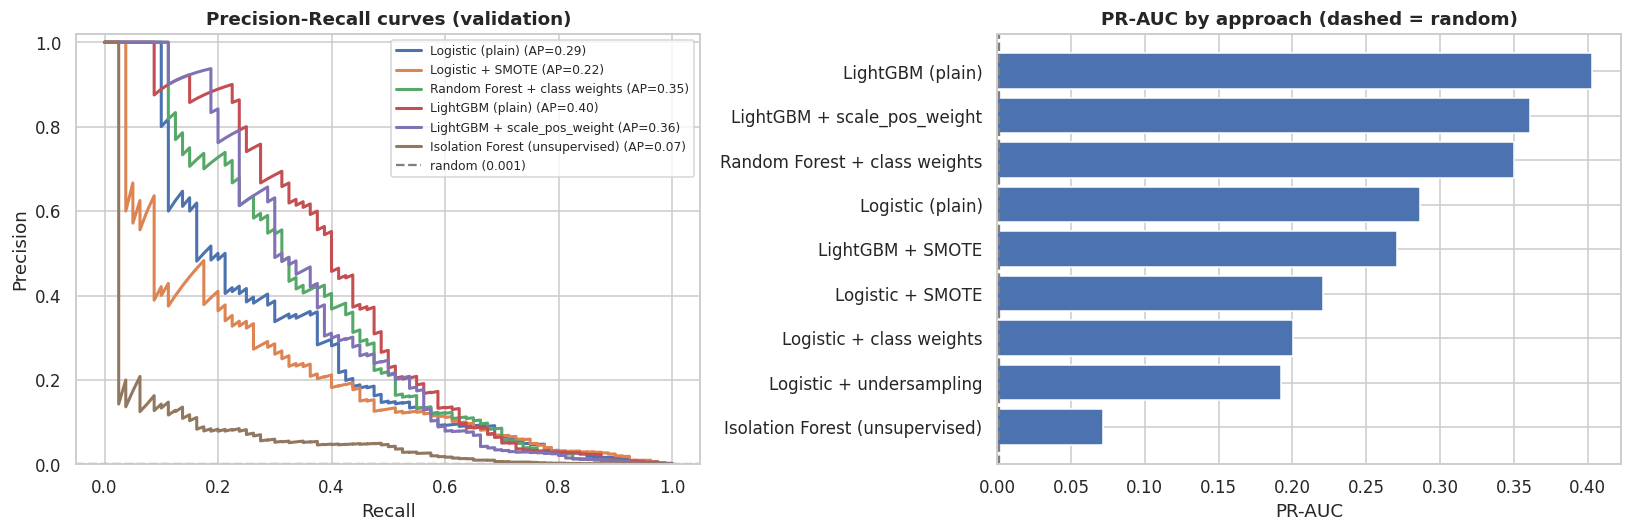

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
show = ["Logistic (plain)", "Logistic + SMOTE", "Random Forest + class weights",
        "LightGBM (plain)", "LightGBM + scale_pos_weight", "Isolation Forest (unsupervised)"]
for n in show:
    p, r, _ = precision_recall_curve(yva, val_scores[n])
    ax[0].plot(r, p, label=f"{n} (AP={val_results.loc[n, 'PR-AUC']:.2f})", lw=2)
ax[0].axhline(BASE_RATE_VAL, color="grey", ls="--", label=f"random ({BASE_RATE_VAL:.3f})")
ax[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves (validation)", ylim=(0, 1.02))
ax[0].legend(fontsize=8)

order = val_results.drop(index="Random guessing").sort_values("PR-AUC")
ax[1].barh(order.index, order["PR-AUC"], color="#4C72B0")
ax[1].axvline(BASE_RATE_VAL, color="grey", ls="--")
ax[1].set(xlabel="PR-AUC", title="PR-AUC by approach (dashed = random)")
plt.tight_layout(); plt.show()

### Is the ranking stable? Cross-validation on the training data
The validation window contains only ~70 frauds, so the ranking could be luck. We check with 5-fold stratified CV on the training set (resamplers are applied *inside* each fold). Random Forest is skipped because it is slow.

In [12]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
cv_rows = []
for name in ["Logistic (plain)", "Logistic + class weights", "Logistic + SMOTE", "Logistic + undersampling",
             "LightGBM (plain)", "LightGBM + scale_pos_weight", "LightGBM + SMOTE"]:
    s = cross_val_score(models[name], Xtr, ytr, cv=cv, scoring="average_precision", n_jobs=1)
    cv_rows.append({"Model": name, "CV PR-AUC (mean)": s.mean(), "± std": s.std()})
    print(f"✓ {name}")
cv_results = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV PR-AUC (mean)", ascending=False)
display(cv_results.round(3))

✓ Logistic (plain)


✓ Logistic + class weights


✓ Logistic + SMOTE


✓ Logistic + undersampling


✓ LightGBM (plain)


✓ LightGBM + scale_pos_weight


✓ LightGBM + SMOTE


,CV PR-AUC (mean),± std
Model,,
LightGBM (plain),0.362,0.057
LightGBM + scale_pos_weight,0.318,0.056
LightGBM + SMOTE,0.273,0.056
Logistic (plain),0.205,0.041
Logistic + SMOTE,0.187,0.040
Logistic + undersampling,0.177,0.039
Logistic + class weights,0.167,0.038


### Choosing the final model
We pick the supervised model with the best **validation PR-AUC**, with CV used as a sanity check on the ranking.

In [13]:
supervised = val_results.drop(index=["Random guessing", "Isolation Forest (unsupervised)"])
FINAL_NAME = supervised["PR-AUC"].idxmax()
final_model = models[FINAL_NAME]
print("Selected model:", FINAL_NAME)

Selected model: LightGBM (plain)


## 7. From scores to decisions: a cost-based threshold

A model outputs a *score*; the business needs a *rule*. Assume:
- every flagged transaction costs **₹`REVIEW_COST`** (analyst time + customer friction), whether or not it is fraud
- every fraud we flag is **stopped**, saving its transaction amount

**Net benefit = ₹ fraud stopped − ₹ review cost × alerts.** We pick the number of alerts that maximises this **on the validation set**.

Optimal on validation → flag score ≥ 0.0103  (622 alerts = 0.93% of txns)
Net benefit on validation: ₹279,247


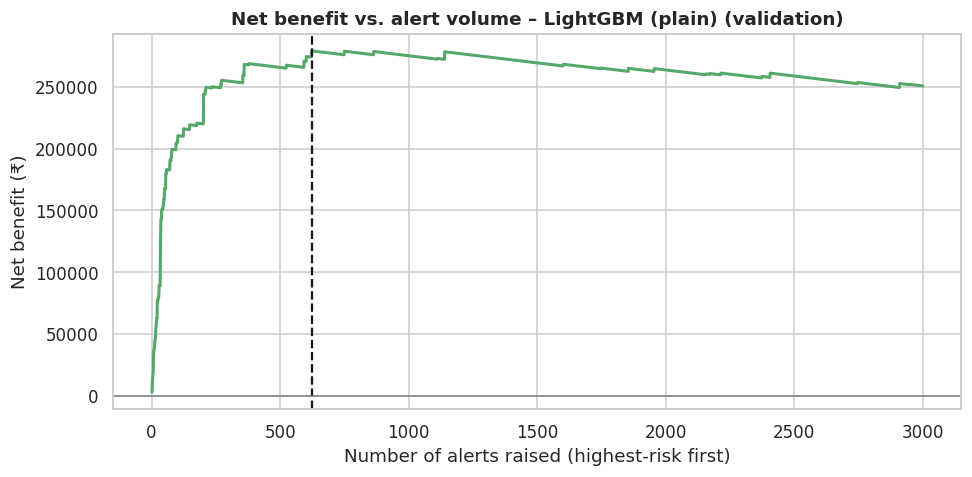

In [14]:
REVIEW_COST = 25   # ₹ per flagged transaction (assumption, change me!)

def benefit_curve(y, amount, score, review_cost):
    order = np.argsort(-np.asarray(score))
    saved = np.cumsum(np.asarray(amount)[order] * np.asarray(y)[order])
    cost = review_cost * np.arange(1, len(order) + 1)
    return saved - cost, np.asarray(score)[order]

def best_threshold(y, amount, score, review_cost):
    net, sorted_scores = benefit_curve(y, amount, score, review_cost)
    k = int(np.argmax(net))
    return sorted_scores[k], k + 1, net[k]

s_val = val_scores[FINAL_NAME]
thr, k_alerts, best_net = best_threshold(yva, val.amount, s_val, REVIEW_COST)
print(f"Optimal on validation → flag score ≥ {thr:.4f}  ({k_alerts} alerts = {k_alerts/len(yva):.2%} of txns)")
print(f"Net benefit on validation: ₹{best_net:,.0f}")

net, _ = benefit_curve(yva, val.amount, s_val, REVIEW_COST)
plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(net) + 1)[:3000], net[:3000], lw=2, color="#55A868")
plt.axvline(k_alerts, ls="--", color="k"); plt.axhline(0, color="grey", lw=1)
plt.xlabel("Number of alerts raised (highest-risk first)"); plt.ylabel("Net benefit (₹)")
plt.title(f"Net benefit vs. alert volume – {FINAL_NAME} (validation)")
plt.tight_layout(); plt.show()

**Sensitivity:** the right threshold depends on the business. If reviews are cheap, flag more; if every alert is expensive, flag fewer.

In [15]:
rows = []
for rc in [5, 25, 100, 500, 2000]:
    th, k, nb_ = best_threshold(yva, val.amount, s_val, rc)
    flagged = s_val >= th
    rows.append({"review cost (₹)": rc, "alerts": k, "% of txns flagged": 100 * k / len(yva),
                 "precision": yva[flagged].mean(), "recall": yva[flagged].sum() / yva.sum(),
                 "net benefit (₹)": nb_})
display(pd.DataFrame(rows).set_index("review cost (₹)").round(3))

,alerts,% of txns flagged,precision,recall,net benefit (₹)
review cost (₹),,,,,
5,2950,4.434,0.024,0.875,311075.48
25,622,0.935,0.087,0.675,279247.46
100,360,0.541,0.136,0.612,241310.04
500,78,0.117,0.449,0.438,162456.28
2000,39,0.059,0.667,0.325,73745.44


## 8. Final evaluation on the untouched test set
Here the chosen model and the validation-chosen threshold are used **once**. Because the test set contains few frauds, we also bootstrap a confidence interval instead of trusting one number.

In [16]:
s_te = final_model.predict_proba(Xte)[:, 1]
test_eval = pd.DataFrame([evaluate(FINAL_NAME, yte, s_te),
                          evaluate("Random guessing", yte, np.random.default_rng(1).random(len(yte)))]).set_index("Model")
display(test_eval.round(3))

# bootstrap 95% CI for PR-AUC
rng = np.random.default_rng(SEED); n = len(yte); yt = yte.values
boots = []
for _ in range(300):
    idx = rng.integers(0, n, n)
    if yt[idx].sum() > 0: boots.append(average_precision_score(yt[idx], s_te[idx]))
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"\nTest PR-AUC = {average_precision_score(yte, s_te):.3f}  (95% bootstrap CI: {lo:.3f} – {hi:.3f}); "
      f"random baseline = {yte.mean():.4f}")
print(f"→ roughly {average_precision_score(yte, s_te) / yte.mean():.0f}× better than random guessing")

,PR-AUC,ROC-AUC,Precision@0.3%,Recall@0.3%
Model,,,,
LightGBM (plain),0.308,0.968,0.157,0.553
Random guessing,0.001,0.480,0.000,0.000



Test PR-AUC = 0.308  (95% bootstrap CI: 0.212 – 0.418); random baseline = 0.0009
→ roughly 360× better than random guessing


Operating point: flag score ≥ 0.0103  (chosen on validation)
  Alerts raised        : 842  (0.95% of 88,805 txns)
  Frauds caught        : 51 of 76  → recall 67.1%
  Precision            : 6.1%  (791 false alarms)
  Fraud ₹ stopped      : ₹301,713 of ₹344,033 (87.7%)
  Review cost          : ₹21,050
  NET BENEFIT          : ₹280,663   (doing nothing = ₹0)


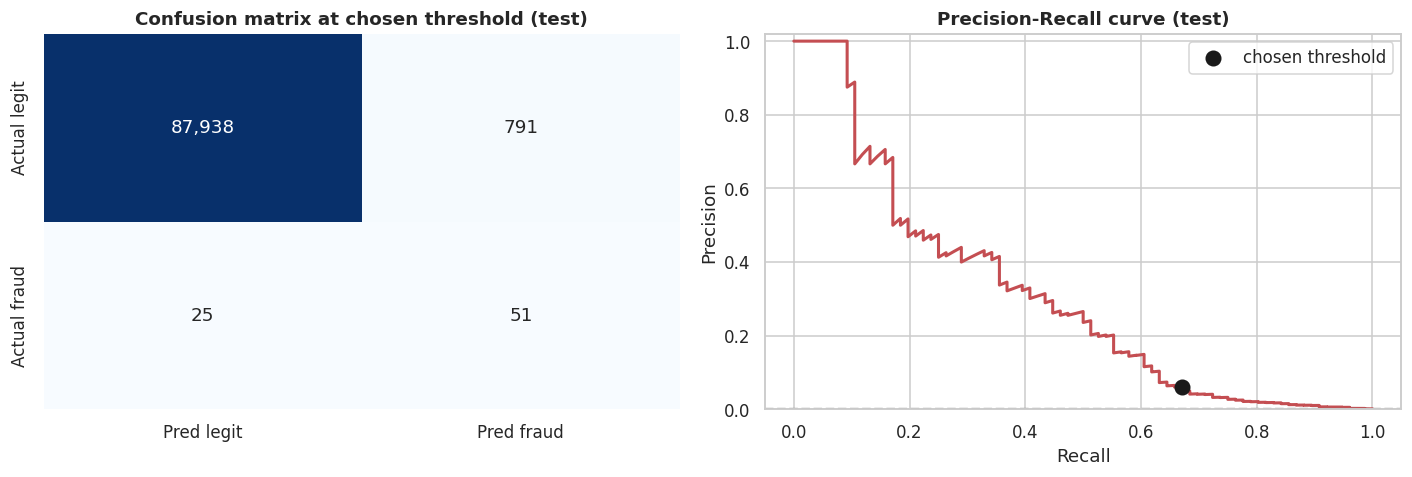

In [17]:
flagged = s_te >= thr
tn, fp, fn, tp = confusion_matrix(yte, flagged).ravel()
fraud_amt_total = test.loc[yte == 1, "amount"].sum()
fraud_amt_caught = test.loc[flagged & (yte == 1), "amount"].sum()
net_test = fraud_amt_caught - REVIEW_COST * flagged.sum()

print(f"Operating point: flag score ≥ {thr:.4f}  (chosen on validation)")
print(f"  Alerts raised        : {flagged.sum():,}  ({flagged.mean():.2%} of {len(yte):,} txns)")
print(f"  Frauds caught        : {tp} of {tp+fn}  → recall {tp/(tp+fn):.1%}")
print(f"  Precision            : {tp/max(tp+fp,1):.1%}  ({fp} false alarms)")
print(f"  Fraud ₹ stopped      : ₹{fraud_amt_caught:,.0f} of ₹{fraud_amt_total:,.0f} ({fraud_amt_caught/fraud_amt_total:.1%})")
print(f"  Review cost          : ₹{REVIEW_COST * flagged.sum():,.0f}")
print(f"  NET BENEFIT          : ₹{net_test:,.0f}   (doing nothing = ₹0)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Actual legit", "Actual fraud"])
ax[0].set_title("Confusion matrix at chosen threshold (test)")
p, r, _ = precision_recall_curve(yte, s_te)
ax[1].plot(r, p, lw=2, color="#C44E52"); ax[1].axhline(yte.mean(), color="grey", ls="--")
ax[1].scatter([tp / (tp + fn)], [tp / max(tp + fp, 1)], s=90, color="k", zorder=5, label="chosen threshold")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve (test)", ylim=(0, 1.02)); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Failure analysis: who do we miss, and who do we wrongly flag?
Because we simulated the data, we know *why* each transaction looks the way it does, something you never get with real data, but ideal for understanding model behaviour.

In [18]:
fr = test[yte == 1].assign(caught=flagged[yte.values == 1])
by_kind = fr.groupby("_kind").agg(frauds=("caught", "size"), caught=("caught", "sum"))
by_kind["recall"] = by_kind["caught"] / by_kind["frauds"]
by_stealth = fr.groupby("_stealth").agg(frauds=("caught", "size"), caught=("caught", "sum"))
by_stealth["recall"] = by_stealth["caught"] / by_stealth["frauds"]
by_stealth.index = by_stealth.index.map({0: "obvious fraud", 1: "stealth fraud"})
display(by_kind.round(2)); display(by_stealth.round(2))

fp_rows = test[flagged & (yte.values == 0)]
hn_share = fp_rows["_hard_negative"].mean() if len(fp_rows) else float("nan")
print(f"\nFalse alarms: {len(fp_rows)} | of which 'hard negatives' (legit but suspicious-looking): {hn_share:.0%} "
      f"(they are only {test['_hard_negative'].mean():.1%} of all legit transactions)")

,frauds,caught,recall
_kind,,,
collect_scam,51,36,0.71
mule,9,5,0.56
takeover,16,10,0.62


,frauds,caught,recall
_stealth,,,
obvious fraud,52,47,0.90
stealth fraud,24,4,0.17



False alarms: 791 | of which 'hard negatives' (legit but suspicious-looking): 54% (they are only 1.8% of all legit transactions)


**Reading this:** stealth fraud, which imitates normal behaviour, is much harder to catch, and most false alarms come from the small group of legitimate customers who *genuinely behave unusually*. No amount of resampling tricks fixes that; it needs **new information** (device fingerprints, beneficiary reputation, graph features, real-time velocity).

## 10. Explainability: what drives the fraud score?
Fraud teams must justify why a transaction was flagged. We use permutation importance (how much PR-AUC drops when a feature is shuffled) on the validation set.

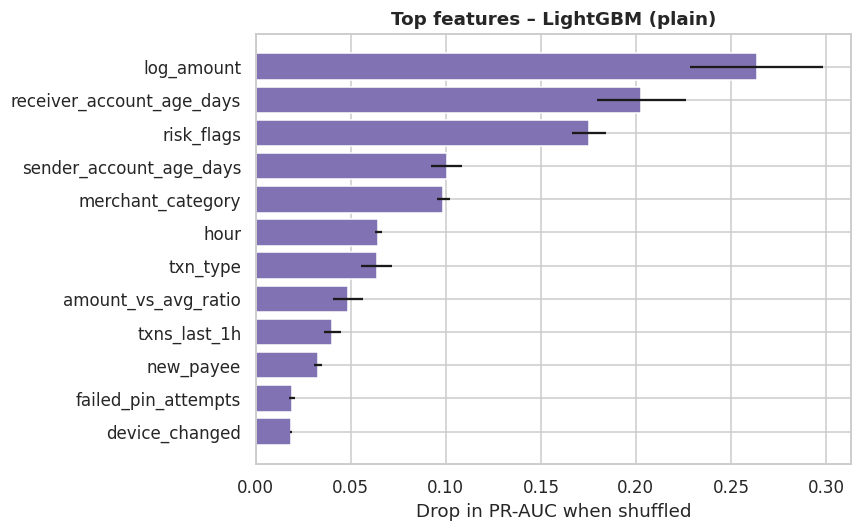

In [19]:
imp = permutation_importance(final_model, Xva, yva, scoring="average_precision",
                             n_repeats=3, random_state=SEED, n_jobs=-1)
imp_df = pd.DataFrame({"feature": ALL_FEATURES, "importance": imp.importances_mean,
                       "std": imp.importances_std}).sort_values("importance")
imp_df = imp_df[imp_df.importance > 0].tail(12)
plt.figure(figsize=(8, 5))
plt.barh(imp_df.feature, imp_df.importance, xerr=imp_df["std"], color="#8172B3")
plt.xlabel("Drop in PR-AUC when shuffled"); plt.title(f"Top features – {FINAL_NAME}")
plt.tight_layout(); plt.show()

## 11. Save the model & score a new transaction

In [20]:
import os; os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/fraud_model.joblib")
json.dump({"model": FINAL_NAME, "threshold": float(thr), "review_cost_inr": REVIEW_COST,
           "features": ALL_FEATURES}, open("models/config.json", "w"), indent=2)

def score_transaction(txn: dict):
    row = pd.DataFrame([{**txn, "timestamp": pd.Timestamp("2025-03-20")}])
    row["sender_avg_amount"] = txn["amount"] / txn["amount_vs_avg_ratio"]
    X = add_features(row)[ALL_FEATURES]
    s = float(final_model.predict_proba(X)[:, 1][0])
    return {"risk_score": round(s, 4), "action": "REVIEW / BLOCK" if s >= thr else "ALLOW"}

normal = dict(txn_type="P2M", merchant_category="grocery", amount=420, amount_vs_avg_ratio=1.0, hour=18,
              sender_account_age_days=900, receiver_account_age_days=1500, device_changed=0, new_payee=0,
              location_mismatch=0, txns_last_1h=0, failed_pin_attempts=0)
suspicious = dict(txn_type="P2P", merchant_category="none", amount=45000, amount_vs_avg_ratio=12.0, hour=2,
                  sender_account_age_days=700, receiver_account_age_days=12, device_changed=1, new_payee=1,
                  location_mismatch=1, txns_last_1h=3, failed_pin_attempts=2)
print("Normal grocery payment  →", score_transaction(normal))
print("Suspicious late-night   →", score_transaction(suspicious))

Normal grocery payment  → {'risk_score': 0.0, 'action': 'ALLOW'}
Suspicious late-night   → {'risk_score': 0.8398, 'action': 'REVIEW / BLOCK'}


## 12. Conclusions, limitations & next steps

**What we found** (numbers from this run, seed 42)
1. **Accuracy is meaningless** at 0.1% prevalence: a model that flags nothing scores 99.9%.
2. **Resampling did not help.** Plain LightGBM beat its class-weighted and SMOTE variants on both validation PR-AUC (0.40 vs 0.36 vs 0.27) and 5-fold CV. For logistic regression, SMOTE/undersampling/class weights also failed to beat the plain model. With only ~250 training frauds, SMOTE interpolates between a handful of points (and our features are mostly binary flags), producing unrealistic synthetic fraud; reweighting mainly shifts scores rather than improving their *ranking*. Resampling changes the decision boundary and calibration, but a **cost-based threshold** achieves the same goal more cleanly.
3. **Model family mattered more than the imbalance trick.** Tree models beat linear ones by ~0.1 PR-AUC because fraud is a *combination* of weak signals (interactions).
4. **Unsupervised anomaly detection is a weak substitute for labels** (PR-AUC ≈ 0.07), though still far above random (0.001). It is useful only when labelled fraud is unavailable.
5. **On the untouched test set**, the chosen model reached PR-AUC ≈ 0.31 (95% CI ≈ 0.21 – 0.42), roughly 360× better than random, and with a ₹25 review cost caught about two-thirds of frauds but ~88% of fraud *value*, because it prioritises large transactions.
6. **Errors are structural:** stealth fraud (~17% recall vs ~90% for obvious fraud) and genuinely unusual customers (more than half of the false alarms) can't be fixed by tuning, they need new signals.

**Limitations (be honest about these)**
- Data is **simulated**; real fraud is adversarial and messier, so absolute metrics don't transfer, only the methodology does.
- The test set has only ~76 frauds → wide confidence intervals.
- No label delay (real fraud reports arrive days later), no graph/network features, no drift monitoring.
- Scores from weighted or resampled models are **not calibrated probabilities**.
- Review cost and "fraud stopped = full amount" are simplifying assumptions.

**Next steps**
- Time-series cross-validation, periodic retraining and drift monitoring (PSI).
- Graph features (shared devices, payee fan-in) to catch mule rings.
- Probability calibration, SHAP-based per-alert reasons, and a Streamlit/FastAPI scoring service.
- Re-run the same pipeline on a real public dataset (e.g. the Kaggle credit-card fraud data) to validate the methodology.